✓ Ready
Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260510_143013.jpg
Main contour area: 708012 px
Kept: 1565 inside, 553 near edge/bottom


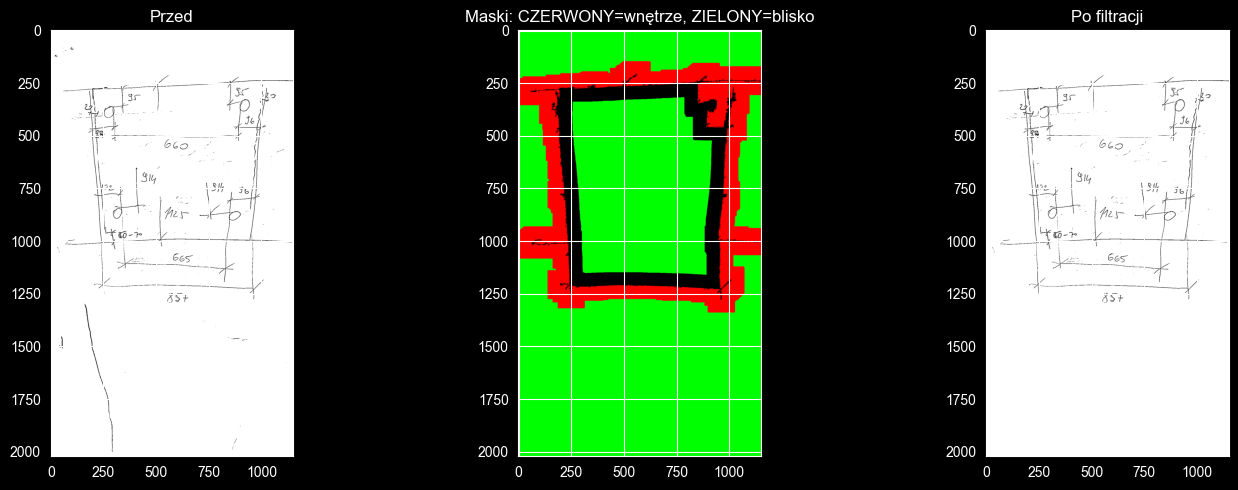


ETAP 1: Wykrywanie linii poziomych i pionowych (razem)
Wykryto linii poziomych/pionowych: 49


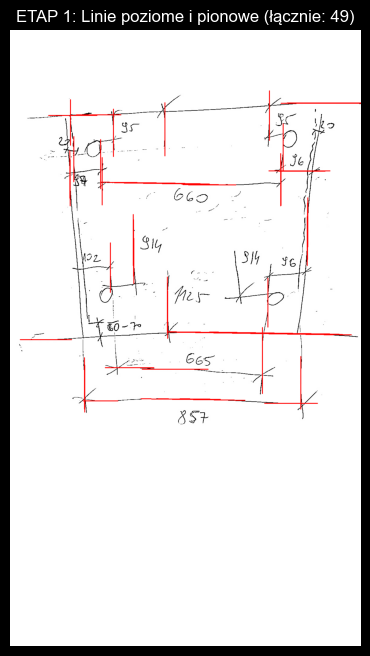


ETAP 2: Wykrywanie okręgów
Wykryto okręgów: 0


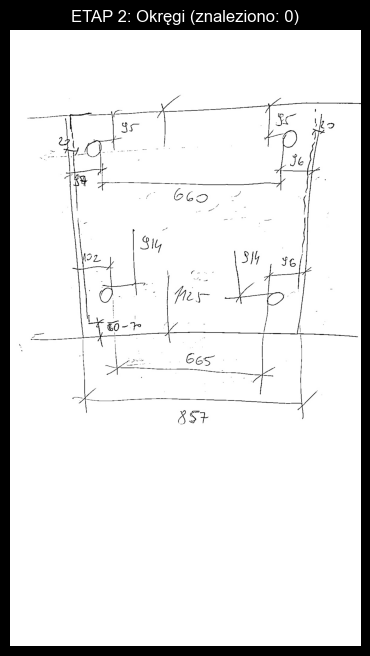


ETAP 3: Wykrywanie ticków (linie 45° i 135°)
Wykryto ticków (linie 45°): 80


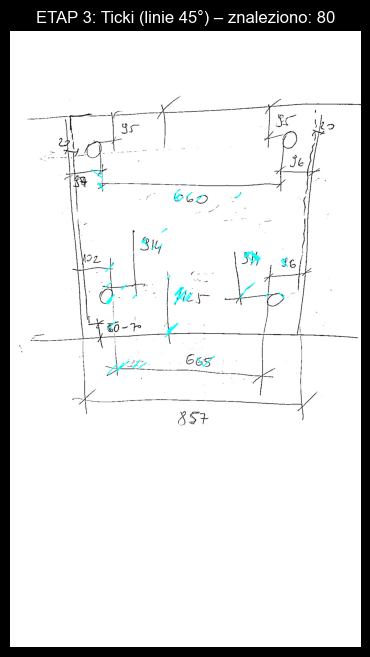


ETAP 4: Budowanie węzłów i klasyfikacja połączeń
  Węzłów ogółem: 188
  Krawędzi głównych: 49
  Ticków (jako krawędzie): 80
  Węzłów z stopniem >=2 (narożniki/rozgałęzienia): 4


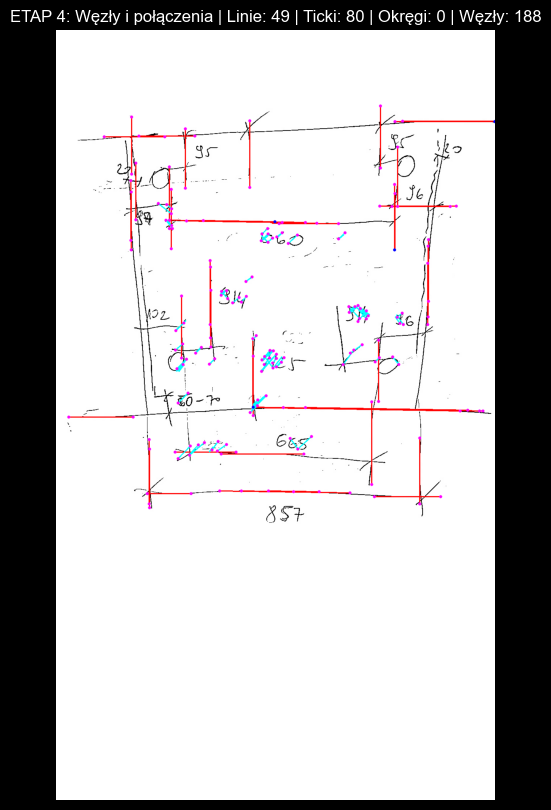


ETAP 5: Zapis wyników do JSON

✅ Zapisano:
   JSON: C:\python\Intelligent_Sketch2CAD\intermediate_data\technical_drawing_new_20260510_231842.json
   Wizualizacja: C:\python\Intelligent_Sketch2CAD\intermediate_data\technical_drawing_new_20260510_231842.jpg

Podsumowanie:
   Linie główne (poziome/pionowe): 49
   Ticki (45°): 80
   Okręgi: 0
   Węzły: 188 (w tym narożne: 4)

▶ Gotowe do importu do FreeCAD


In [1]:
# -------------------------------
# VERTICAL SLICE: SKETCH → TECHNICAL DRAWING
# Nowe podejście: morfologia + Hough + okręgi + ticki + węzły
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import json
from datetime import datetime
from collections import defaultdict

print("✓ Ready")

# -------------------------------
# PATHS
# -------------------------------
PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------
# LOAD LATEST IMAGE
# -------------------------------
pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)
latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
if len(image.shape) == 3:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
else:
    gray = image

# Fix polarity (white background, black lines)
if np.mean(gray) < 128:
    gray = cv2.bitwise_not(gray)
    print("Polarity fixed")

# -------------------------------
# Poprawione filtrowanie komponentów
# -------------------------------
contour_img = cv2.bitwise_not(gray)
contours, _ = cv2.findContours(contour_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    print("No contours found – keeping original")
    gray_filtered = gray
else:
    main_contour = max(contours, key=cv2.contourArea)
    area_main = cv2.contourArea(main_contour)
    print(f"Main contour area: {area_main:.0f} px")

    mask_inside = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_inside, [main_contour], -1, 255, thickness=cv2.FILLED)

    mask_edge = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_edge, [main_contour], -1, 255, thickness=2)
    kernel_large = np.ones((120, 120), np.uint8)
    mask_near = cv2.dilate(mask_edge, kernel_large, iterations=1)
    mask_near_or_bottom = mask_near

    cc_img = cv2.bitwise_not(gray)
    _, labels, stats, _ = cv2.connectedComponentsWithStats(cc_img, connectivity=8)

    mask_final = np.zeros_like(gray, dtype=np.uint8)
    MAX_AREA_SMALL = 1500

    kept_inside = 0
    kept_near = 0

    for label in range(1, len(stats)):
        comp_mask = (labels == label).astype(np.uint8) * 255
        area = stats[label, cv2.CC_STAT_AREA]

        if cv2.bitwise_and(comp_mask, mask_inside).any():
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
            kept_inside += 1
            continue

        in_near = cv2.bitwise_and(comp_mask, mask_near_or_bottom)
        if in_near.any() and area < MAX_AREA_SMALL:
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
            kept_near += 1
            continue

    print(f"Kept: {kept_inside} inside, {kept_near} near edge/bottom")

    gray_filtered = cv2.bitwise_and(gray, mask_final)
    gray_filtered[mask_final == 0] = 255

    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title("Przed")
    plt.subplot(1,3,2)
    viz = np.zeros((*gray.shape, 3), dtype=np.uint8)
    viz[mask_inside==0] = [255,0,0]
    viz[mask_near_or_bottom == 0] = [0,255,0]
    plt.imshow(viz)
    plt.title("Maski: CZERWONY=wnętrze, ZIELONY=blisko")
    plt.subplot(1,3,3); plt.imshow(gray_filtered, cmap='gray'); plt.title("Po filtracji")
    plt.tight_layout()
    plt.show()

    gray = gray_filtered

# ============================================================
# NOWY PIPELINE (zamiast LSD)
# ============================================================

# Przygotowanie obrazu roboczego (białe linie na czarnym tle dla morfologii)
binary_lines_white = cv2.bitwise_not(gray)  # teraz linie = 255, tło = 0

print("\n" + "="*60)
print("ETAP 1: Wykrywanie linii poziomych i pionowych (razem)")
print("="*60)

# ---------- Linie poziome ----------
kernel_horiz = cv2.getStructuringElement(cv2.MORPH_RECT, (50, 1))
horiz_lines = cv2.morphologyEx(binary_lines_white, cv2.MORPH_OPEN, kernel_horiz)
horiz_lines = cv2.dilate(horiz_lines, kernel_horiz, iterations=2)

# ---------- Linie pionowe ----------
kernel_vert = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 50))
vert_lines = cv2.morphologyEx(binary_lines_white, cv2.MORPH_OPEN, kernel_vert)
vert_lines = cv2.dilate(vert_lines, kernel_vert, iterations=2)

# ---------- Połącz poziome i pionowe ----------
hv_lines = cv2.bitwise_or(horiz_lines, vert_lines)

# ---------- HoughLinesP ----------
min_line_len = max(30, int(min(gray.shape) * 0.1))
max_line_gap = 30
threshold = 50

lines_hv = cv2.HoughLinesP(hv_lines, rho=1, theta=np.pi/180, threshold=threshold,
                           minLineLength=min_line_len, maxLineGap=max_line_gap)

all_hv_lines = []
if lines_hv is not None:
    for line in lines_hv:
        x1, y1, x2, y2 = line[0]
        all_hv_lines.append([int(x1), int(y1), int(x2), int(y2)])

print(f"Wykryto linii poziomych/pionowych: {len(all_hv_lines)}")

# Wizualizacja ETAP 1
vis_hv = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for (x1,y1,x2,y2) in all_hv_lines:
    cv2.line(vis_hv, (x1,y1), (x2,y2), (255,0,0), 2)

plt.figure(figsize=(12,8))
plt.imshow(vis_hv)
plt.title(f"ETAP 1: Linie poziome i pionowe (łącznie: {len(all_hv_lines)})")
plt.axis('off')
plt.show()

# ============================================================
print("\n" + "="*60)
print("ETAP 2: Wykrywanie okręgów")
print("="*60)

# Przygotowanie obrazu dla okręgów (czarne tło, białe linie)
circles_img = binary_lines_white.copy()

# Użyj HoughCircles
dp = 1
minDist = 20
param1 = 50
param2 = 30
minRadius = 5
maxRadius = 60

circles = cv2.HoughCircles(circles_img, cv2.HOUGH_GRADIENT, dp, minDist,
                           param1=param1, param2=param2,
                           minRadius=minRadius, maxRadius=maxRadius)

detected_circles = []
if circles is not None:
    circles = np.round(circles[0, :]).astype("int")
    for (x, y, r) in circles:
        # Weryfikacja: czy okrąg pokrywa się z czarnymi pikselami (na gray_filtered)
        mask_circle = np.zeros_like(gray, dtype=np.uint8)
        cv2.circle(mask_circle, (x, y), r, 255, thickness=1)
        overlap = cv2.bitwise_and(gray, mask_circle)
        coverage = np.sum(overlap == 0) / np.sum(mask_circle == 255) if np.sum(mask_circle == 255) > 0 else 0
        if coverage > 0.6:  # co najmniej 60% obwodu to czarne piksele
            detected_circles.append([int(x), int(y), int(r)])
            print(f"  Okrąg: x={x}, y={y}, r={r}, coverage={coverage:.2f}")

print(f"Wykryto okręgów: {len(detected_circles)}")

# Wizualizacja ETAP 2
vis_circles = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for (x, y, r) in detected_circles:
    cv2.circle(vis_circles, (x, y), r, (0, 255, 0), 2)
    cv2.circle(vis_circles, (x, y), 2, (0, 0, 255), 3)

plt.figure(figsize=(12,8))
plt.imshow(vis_circles)
plt.title(f"ETAP 2: Okręgi (znaleziono: {len(detected_circles)})")
plt.axis('off')
plt.show()

# ============================================================
print("\n" + "="*60)
print("ETAP 3: Wykrywanie ticków (linie 45° i 135°)")
print("="*60)

# Przygotowanie obrazu ticków
ticks_img = binary_lines_white.copy()

# Kernel dla 45° (przekątna)
kernel_45 = np.array([[0,0,1,0,0],
                      [0,0,1,0,0],
                      [0,0,1,0,0],
                      [0,0,1,0,0],
                      [0,0,1,0,0]], dtype=np.uint8) * 255

kernel_135 = np.array([[0,0,0,0,1],
                       [0,0,0,1,0],
                       [0,0,1,0,0],
                       [0,1,0,0,0],
                       [1,0,0,0,0]], dtype=np.uint8) * 255

# Morfologia dla obu kierunków
diag45 = cv2.morphologyEx(ticks_img, cv2.MORPH_OPEN, kernel_45)
diag135 = cv2.morphologyEx(ticks_img, cv2.MORPH_OPEN, kernel_135)

# Połącz i rozszerz
diag_lines = cv2.bitwise_or(diag45, diag135)
diag_lines = cv2.dilate(diag_lines, np.ones((3,3), np.uint8), iterations=1)

# HoughLinesP dla ticków (krótkie segmenty)
tick_min_len = 10
tick_max_gap = 10
tick_threshold = 30

tick_lines_raw = cv2.HoughLinesP(diag_lines, rho=1, theta=np.pi/180, threshold=tick_threshold,
                                 minLineLength=tick_min_len, maxLineGap=tick_max_gap)

# Filtracja ticków: tylko krótkie (15-50 px) i blisko krawędzi (użyj mask_near)
all_ticks = []
if tick_lines_raw is not None:
    for line in tick_lines_raw:
        x1, y1, x2, y2 = line[0]
        length = np.hypot(x2-x1, y2-y1)

        # Sprawdź kąt (powinien być ok 45° lub 135°)
        angle = np.degrees(np.arctan2(y2-y1, x2-x1)) % 180
        if not (35 < angle < 55 or 125 < angle < 145):
            continue

        # Sprawdź długość (tick = krótki)
        if length < 15 or length > 60:
            continue

        # Sprawdź czy blisko krawędzi (użyj maski z etapu filtracji)
        center_x = (x1 + x2) // 2
        center_y = (y1 + y2) // 2
        if center_y >= gray.shape[0] or center_x >= gray.shape[1] or center_y < 0 or center_x < 0:
            continue

        if mask_near_or_bottom[center_y, center_x] == 0:  # 0 w masce to obszar "blisko" (bo wizualizacja była odwrócona)
            all_ticks.append([int(x1), int(y1), int(x2), int(y2)])

print(f"Wykryto ticków (linie 45°): {len(all_ticks)}")

# Wizualizacja ETAP 3
vis_ticks = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for (x1,y1,x2,y2) in all_ticks:
    cv2.line(vis_ticks, (x1,y1), (x2,y2), (0, 255, 255), 2)  # żółty

plt.figure(figsize=(12,8))
plt.imshow(vis_ticks)
plt.title(f"ETAP 3: Ticki (linie 45°) – znaleziono: {len(all_ticks)}")
plt.axis('off')
plt.show()

# ============================================================
print("\n" + "="*60)
print("ETAP 4: Budowanie węzłów i klasyfikacja połączeń")
print("="*60)

# Połącz wszystkie linie (bez ticków – ticki to osobna kategoria)
all_main_lines = all_hv_lines.copy()

# Budowanie grafu węzłów
proximity_threshold = 8
nodes = []  # lista (x, y)
edges = []  # (node_idx1, node_idx2, line_type, line_idx)

def find_or_add_node(x, y):
    for i, (nx, ny) in enumerate(nodes):
        if abs(nx - x) < proximity_threshold and abs(ny - y) < proximity_threshold:
            return i
    nodes.append((int(x), int(y)))
    return len(nodes) - 1

# Dodaj główne linie (poziome/pionowe)
for idx, (x1, y1, x2, y2) in enumerate(all_main_lines):
    n1 = find_or_add_node(x1, y1)
    n2 = find_or_add_node(x2, y2)
    edges.append((n1, n2, "main", idx))

# Dodaj ticki (jako osobne krawędzie, ale nie wpływają na węzły główne)
tick_edges = []
for idx, (x1, y1, x2, y2) in enumerate(all_ticks):
    n1 = find_or_add_node(x1, y1)
    n2 = find_or_add_node(x2, y2)
    tick_edges.append((n1, n2, "tick", idx))

# Analiza stopnia węzłów
node_degree = defaultdict(int)
for e in edges:
    node_degree[e[0]] += 1
    node_degree[e[1]] += 1

# Węzły narożne (na obrysie – stopień 2 lub więcej)
corner_nodes = [i for i, deg in node_degree.items() if deg >= 2]

print(f"  Węzłów ogółem: {len(nodes)}")
print(f"  Krawędzi głównych: {len(edges)}")
print(f"  Ticków (jako krawędzie): {len(tick_edges)}")
print(f"  Węzłów z stopniem >=2 (narożniki/rozgałęzienia): {len(corner_nodes)}")

# Wizualizacja ETAP 4
vis_nodes = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

# Rysuj główne linie (niebieskie)
for (x1,y1,x2,y2) in all_main_lines:
    cv2.line(vis_nodes, (x1,y1), (x2,y2), (255,0,0), 2)

# Rysuj ticki (żółte)
for (x1,y1,x2,y2) in all_ticks:
    cv2.line(vis_nodes, (x1,y1), (x2,y2), (0,255,255), 2)

# Rysuj okręgi (zielone)
for (x,y,r) in detected_circles:
    cv2.circle(vis_nodes, (x,y), r, (0,255,0), 2)

# Rysuj węzły (czerwone kropki)
for i, (x,y) in enumerate(nodes):
    color = (0,0,255) if i in corner_nodes else (255,0,255)
    cv2.circle(vis_nodes, (x,y), 4, color, -1)

plt.figure(figsize=(14,10))
plt.imshow(vis_nodes)
plt.title(f"ETAP 4: Węzły i połączenia | Linie: {len(all_main_lines)} | Ticki: {len(all_ticks)} | Okręgi: {len(detected_circles)} | Węzły: {len(nodes)}")
plt.axis('off')
plt.show()

# ============================================================
print("\n" + "="*60)
print("ETAP 5: Zapis wyników do JSON")
print("="*60)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

data = {
    "timestamp": timestamp,
    "source_image": str(latest_file),
    "image_shape": list(gray.shape),
    "statistics": {
        "horizontal_vertical_lines": len(all_main_lines),
        "ticks_45deg": len(all_ticks),
        "circles": len(detected_circles),
        "nodes": len(nodes),
        "edges": len(edges)
    },
    "lines": {
        "main": all_main_lines,
        "ticks": all_ticks
    },
    "circles": detected_circles,
    "graph": {
        "nodes": nodes,
        "edges": edges,
        "tick_edges": tick_edges,
        "corner_nodes": corner_nodes
    }
}

json_path = INTERMEDIATE_DIR / f"technical_drawing_new_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)

# Zapisz końcową wizualizację
vis_final = vis_nodes.copy()
final_vis_path = INTERMEDIATE_DIR / f"technical_drawing_new_{timestamp}.jpg"
cv2.imwrite(str(final_vis_path), cv2.cvtColor(vis_final, cv2.COLOR_RGB2BGR))

print(f"\n✅ Zapisano:")
print(f"   JSON: {json_path}")
print(f"   Wizualizacja: {final_vis_path}")
print(f"\nPodsumowanie:")
print(f"   Linie główne (poziome/pionowe): {len(all_main_lines)}")
print(f"   Ticki (45°): {len(all_ticks)}")
print(f"   Okręgi: {len(detected_circles)}")
print(f"   Węzły: {len(nodes)} (w tym narożne: {len(corner_nodes)})")

print("\n▶ Gotowe do importu do FreeCAD")